In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 31.3 MB/s eta 0:00:00


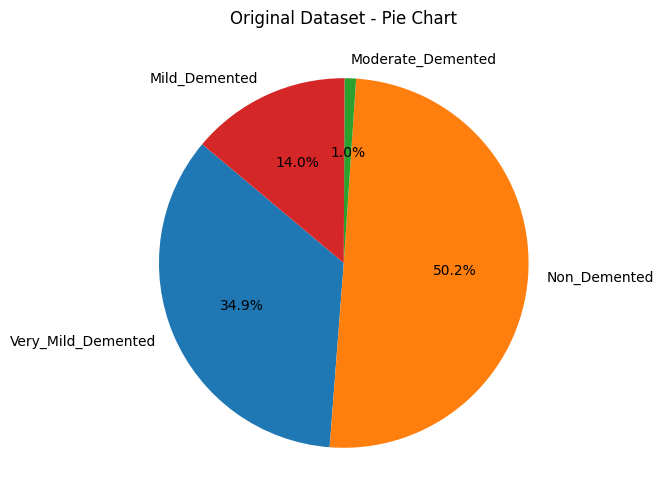

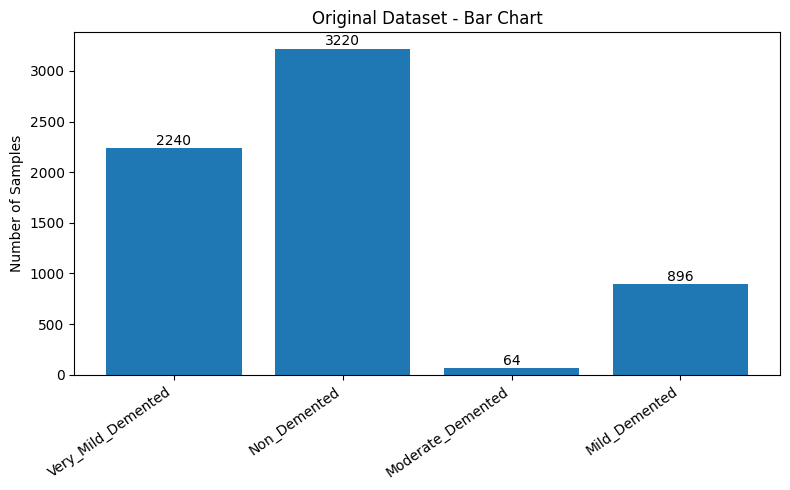

Train samples      : 4494
Validation samples : 963
Test samples       : 963


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Epoch 1 | Train Loss: 1.1097 | Train Acc: 0.4820 | Train F1: 0.4820 | Val Loss: 0.9985 | Val Acc: 0.4735 | Val F1: 0.4735
Epoch 2 | Train Loss: 0.9606 | Train Acc: 0.5338 | Train F1: 0.5338 | Val Loss: 0.9429 | Val Acc: 0.5659 | Val F1: 0.5659
Epoch 3 | Train Loss: 0.9055 | Train Acc: 0.5612 | Train F1: 0.5612 | Val Loss: 0.8904 | Val Acc: 0.5566 | Val F1: 0.5566
Epoch 4 | Train Loss: 0.8780 | Train Acc: 0.5703 | Train F1: 0.5703 | Val Loss: 0.8515 | Val Acc: 0.5826 | Val F1: 0.5826
Epoch 5 | Train Loss: 0.8609 | Train Acc: 0.5846 | Train F1: 0.5846 | Val Loss: 0.8351 | Val Acc: 0.5826 | Val F1: 0.5826
Epoch 6 | Train Loss: 0.8418 | Train Acc: 0.5837 | Train F1: 0.5837 | Val Loss: 0.8185 | Val Acc: 0.6116 | Val F1: 0.6116
Epoch 7 | Train Loss: 0.8300 | Train Acc: 0.6010 | Train F1: 0.6010 | Val Loss: 0.8309 | Val Acc: 0.6199 | Val F1: 0.6199
Epoch 8 | Train Loss: 0.8080 | Train Acc: 0.6119 | Train F1: 0.6119 | Val Loss: 0.7766 | Val Acc: 0.6490 | Val F1: 0.6490
Epoch 9 | Train Loss: 0.

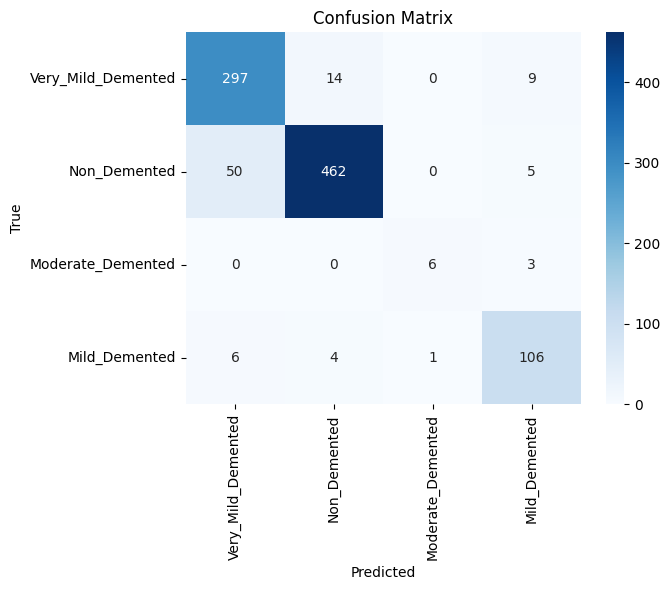

In [ ]:

# ============================================================
# 0️⃣ Install Required Packages
# ============================================================
!pip install timm torchmetrics scikit-learn matplotlib seaborn --quiet


# ============================================================
# 1️⃣ Imports
# ============================================================
import os, random
import numpy as np
import torch
import timm
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms as T
import torchmetrics
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
torch.manual_seed(2025)
np.random.seed(2025)
random.seed(2025)


# ============================================================
# 2️⃣ Custom Dataset Class
# ============================================================
class CustomDataset(Dataset):
    def __init__(self, root, transformations=None, im_files=(".png", ".jpg", ".jpeg")):
        self.transformations = transformations
        self.im_paths = []

        for ext in im_files:
            self.im_paths.extend(glob(os.path.join(root, "*", f"*{ext}")))

        self.cls_names = {}
        self.cls_counts = {}
        count = 0

        for p in self.im_paths:
            cls = self.get_class(p)
            if cls not in self.cls_names:
                self.cls_names[cls] = count
                self.cls_counts[cls] = 1
                count += 1
            else:
                self.cls_counts[cls] += 1

    def get_class(self, path):
        return os.path.basename(os.path.dirname(path))

    def __len__(self):
        return len(self.im_paths)

    def __getitem__(self, idx):
        img = Image.open(self.im_paths[idx]).convert("RGB")
        label = self.cls_names[self.get_class(self.im_paths[idx])]

        if self.transformations:
            img = self.transformations(img)

        return img, label


# ============================================================
# 3️⃣ Visualization
# ============================================================
def visualize_dataset(counts, title):
    labels = list(counts.keys())
    values = list(counts.values())

    plt.figure(figsize=(6,6))
    plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=140)
    plt.title(f"{title} - Pie Chart")
    plt.show()

    plt.figure(figsize=(8,5))
    bars = plt.bar(labels, values)
    plt.title(f"{title} - Bar Chart")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=35, ha="right")

    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 str(val),
                 ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()


# ============================================================
# 4️⃣ Dataset Setup with Augmentation (ORIGINAL DATASET)
# ============================================================
root = "/content/drive/MyDrive/Dataset"   # change if needed
im_size = 224
bs = 32

tfs = T.Compose([
    T.Resize((im_size, im_size)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

dataset = CustomDataset(root, tfs)

visualize_dataset(dataset.cls_counts, "Original Dataset")


# ============================================================
# 5️⃣ Train / Validation / Test Split (NO BALANCING)
# ============================================================
total = len(dataset)
tr_len = int(0.7 * total)
vl_len = int(0.15 * total)
ts_len = total - tr_len - vl_len

print(f"Train samples      : {tr_len}")
print(f"Validation samples : {vl_len}")
print(f"Test samples       : {ts_len}")

train_ds, val_ds, test_ds = random_split(dataset, [tr_len, vl_len, ts_len])

train_dl = DataLoader(train_ds, bs, shuffle=True, num_workers=4)
val_dl   = DataLoader(val_ds, bs, shuffle=False, num_workers=4)
test_dl  = DataLoader(test_ds, 1, shuffle=False, num_workers=4)


# ============================================================
# 6️⃣ TrainValidation Class
# ============================================================
class TrainValidation:
    def __init__(self, model_name, classes, tr_dl, val_dl, device):

        self.model = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=len(classes)
        )

        in_features = self.model.fc.in_features
        self.model.fc = torch.nn.Sequential(
            torch.nn.Dropout(0.6),
            torch.nn.Linear(in_features, len(classes))
        )

        self.model = self.model.to(device)
        self.tr_dl = tr_dl
        self.val_dl = val_dl
        self.device = device

        self.loss_fn = torch.nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=1e-4,
            weight_decay=1e-4
        )

        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='max', factor=0.5, patience=3
        )

        self.f1 = torchmetrics.F1Score(
            task="multiclass",
            num_classes=len(classes)
        ).to(device)

        self.tr_losses, self.val_losses = [], []
        self.tr_accs, self.val_accs = [], []
        self.tr_f1s, self.val_f1s = [], []

        self.best_val_acc = 0
        self.patience = 7
        self.wait = 0

    def run(self, epochs=30):
        for e in range(epochs):

            self.model.train()
            tl, ta = 0, 0
            self.f1.reset()

            for x, y in self.tr_dl:
                x, y = x.to(self.device), y.to(self.device)
                p = self.model(x)
                loss = self.loss_fn(p, y)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                tl += loss.item()
                ta += (p.argmax(1) == y).sum().item()
                self.f1.update(p, y)

            tl /= len(self.tr_dl)
            ta /= len(self.tr_dl.dataset)
            tf1 = self.f1.compute().item()

            self.tr_losses.append(tl)
            self.tr_accs.append(ta)
            self.tr_f1s.append(tf1)

            self.model.eval()
            vl, va = 0, 0
            self.f1.reset()

            with torch.no_grad():
                for x, y in self.val_dl:
                    x, y = x.to(self.device), y.to(self.device)
                    p = self.model(x)
                    loss = self.loss_fn(p, y)

                    vl += loss.item()
                    va += (p.argmax(1) == y).sum().item()
                    self.f1.update(p, y)

            vl /= len(self.val_dl)
            va /= len(self.val_dl.dataset)
            vf1 = self.f1.compute().item()

            self.val_losses.append(vl)
            self.val_accs.append(va)
            self.val_f1s.append(vf1)

            self.scheduler.step(va)

            print(
                f"Epoch {e+1} | "
                f"Train Loss: {tl:.4f} | Train Acc: {ta:.4f} | Train F1: {tf1:.4f} | "
                f"Val Loss: {vl:.4f} | Val Acc: {va:.4f} | Val F1: {vf1:.4f}"
            )

            if va > self.best_val_acc:
                self.best_val_acc = va
                torch.save(self.model.state_dict(), "best_model.pth")
                self.wait = 0
            else:
                self.wait += 1
                if self.wait >= self.patience:
                    print("Early stopping (validation accuracy not improving)")
                    break


# ============================================================
# 7️⃣ Train Model
# ============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

trainer = TrainValidation(
    model_name="resnet50",
    classes=dataset.cls_names,
    tr_dl=train_dl,
    val_dl=val_dl,
    device=device
)

trainer.run(epochs=30)


# ============================================================
# 8️⃣ Evaluation
# ============================================================
trainer.model.load_state_dict(torch.load("best_model.pth"))
trainer.model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        p = trainer.model(x)
        y_true.append(y.item())
        y_pred.append(p.argmax(1).item())

print("\nClassification Report\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(dataset.cls_names.keys())
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(dataset.cls_names.keys()),
    yticklabels=list(dataset.cls_names.keys())
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

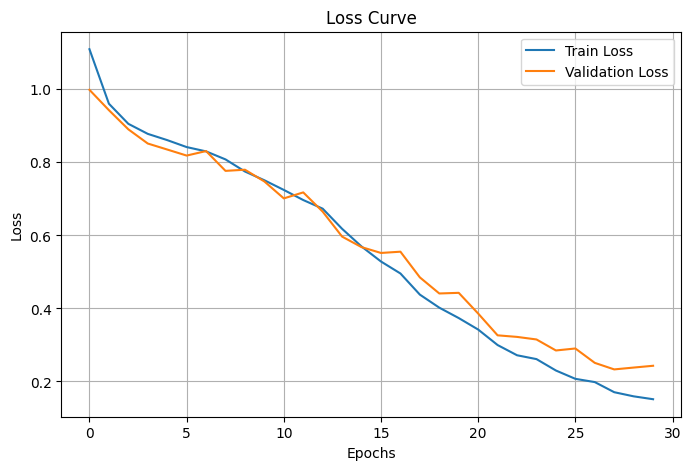

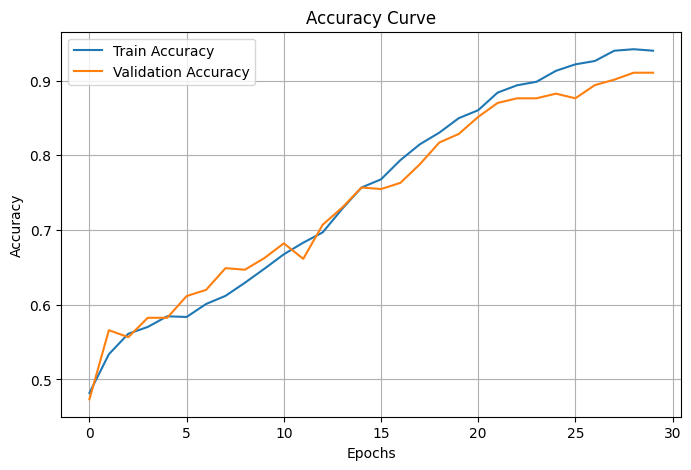

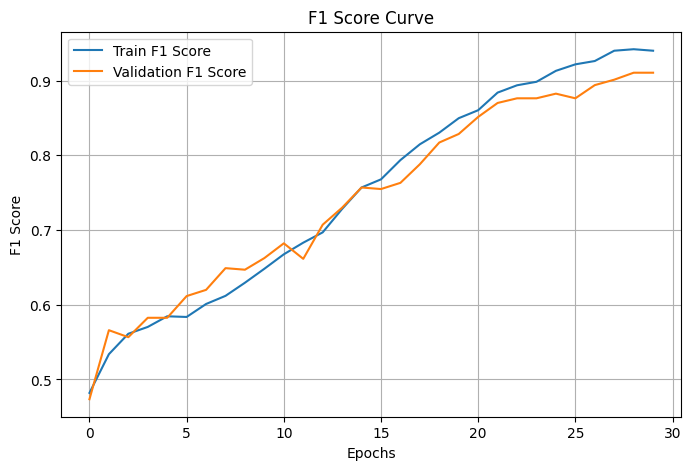

In [ ]:

# ============================================================
# 🔟 Plot Learning Curves
# ============================================================

# Loss Curve
plt.figure(figsize=(8,5))
plt.plot(trainer.tr_losses, label="Train Loss")
plt.plot(trainer.val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(trainer.tr_accs, label="Train Accuracy")
plt.plot(trainer.val_accs, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

# F1 Score Curve
plt.figure(figsize=(8,5))
plt.plot(trainer.tr_f1s, label="Train F1 Score")
plt.plot(trainer.val_f1s, label="Validation F1 Score")
plt.xlabel("Epochs")
plt.ylabel("F1 Score")
plt.title("F1 Score Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve
)

def compute_metrics(y_true, y_pred, y_prob, class_names):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro")
    sensitivity = recall_score(y_true, y_pred, average="macro")  # Recall
    cm = confusion_matrix(y_true, y_pred)

    # Specificity (macro)
    specificity = []
    for i in range(len(class_names)):
        tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
        fp = cm[:,i].sum() - cm[i,i]
        specificity.append(tn / (tn + fp + 1e-8))
    specificity = np.mean(specificity)

    # AUC (one-vs-rest for multiclass)
    auc = roc_auc_score(y_true, y_prob, multi_class="ovr")

    return acc, precision, sensitivity, specificity, auc

In [ ]:

trainer.model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        outputs = trainer.model(x)
        probs = torch.softmax(outputs, dim=1)

        y_true.append(y.item())
        y_pred.append(outputs.argmax(1).item())
        y_prob.append(probs.cpu().numpy()[0])

y_prob = np.array(y_prob)
class_names = list(dataset.cls_names.keys())

acc, prec, sens, spec, auc = compute_metrics(
    y_true, y_pred, y_prob, class_names
)

print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Sensitivity  : {sens:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"AUC (ROC)    : {auc:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Accuracy     : 0.9055
Precision    : 0.9187
Sensitivity  : 0.9415
Specificity  : 0.9627
AUC (ROC)    : 0.9865


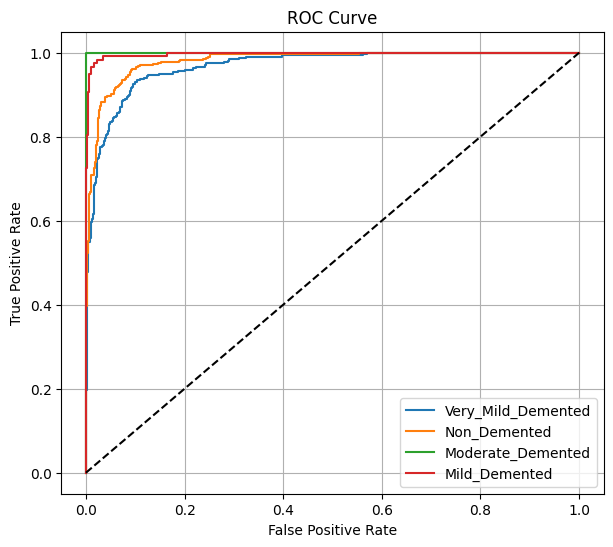

In [ ]:

plt.figure(figsize=(7,6))

for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        np.array(y_true) == i, y_prob[:, i]
    )
    plt.plot(fpr, tpr, label=f"{cls}")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [ ]:

# ============================================================
# 🔟 Grad-CAM for ResNet50 (timm)
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch


def get_last_conv_layer(model):
    """
    Safely get last convolution layer for ResNet (timm / torchvision)
    """
    block = model.layer4[-1]
    return block.conv3 if hasattr(block, "conv3") else block.conv2


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()

        output = self.model(input_tensor)
        score = output[:, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)

        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.squeeze().cpu().numpy()


def overlay_gradcam(image, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return cv2.addWeighted(image, 1 - alpha, heatmap, alpha, 0)


def run_gradcam(model, dataloader, class_names, device, num_images=6):
    model.eval()

    target_layer = get_last_conv_layer(model)
    gradcam = GradCAM(model, target_layer)

    shown = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        preds = model(images).argmax(dim=1)

        for i in range(images.size(0)):

            cam = gradcam.generate(
                images[i].unsqueeze(0),
                preds[i].item()
            )

            # Undo normalization for visualization
            img = images[i].permute(1, 2, 0).cpu().numpy()
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            img = np.uint8(255 * img)

            overlay = overlay_gradcam(img, cam)

            plt.figure(figsize=(4, 4))
            plt.imshow(overlay)
            plt.title(
                f"Pred: {list(class_names.keys())[preds[i].item()]} | "
                f"True: {list(class_names.keys())[labels[i].item()]}"
            )
            plt.axis("off")
            plt.show()

            shown += 1
            if shown >= num_images:
                return

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


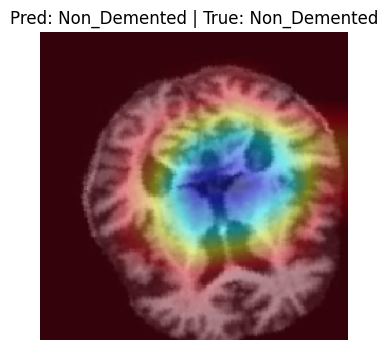

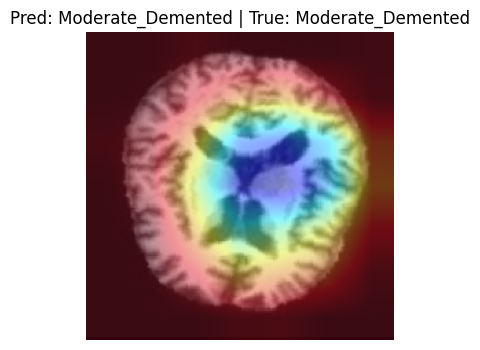

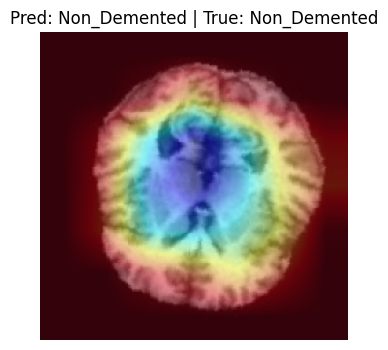

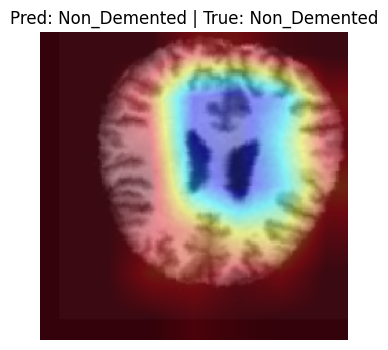

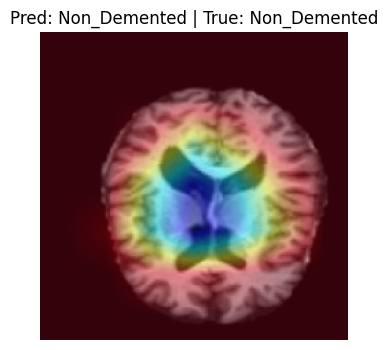

In [ ]:

run_gradcam(
    trainer.model,
    test_dl,
    dataset.cls_names,
    device,
    num_images=5
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.7 MB/s eta 0:00:00


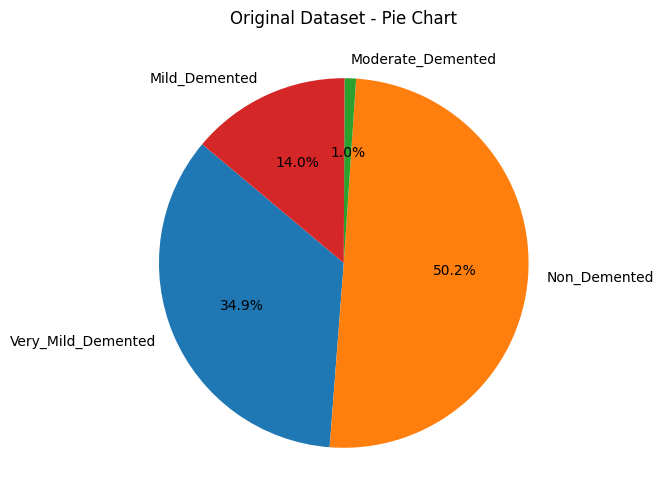

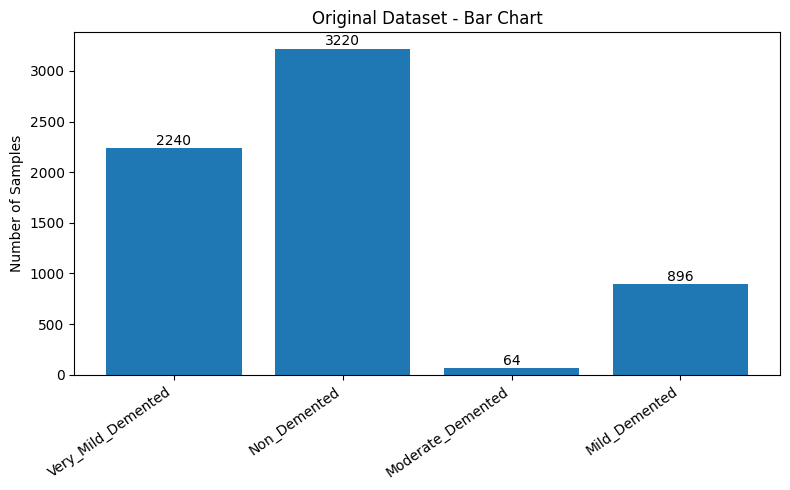

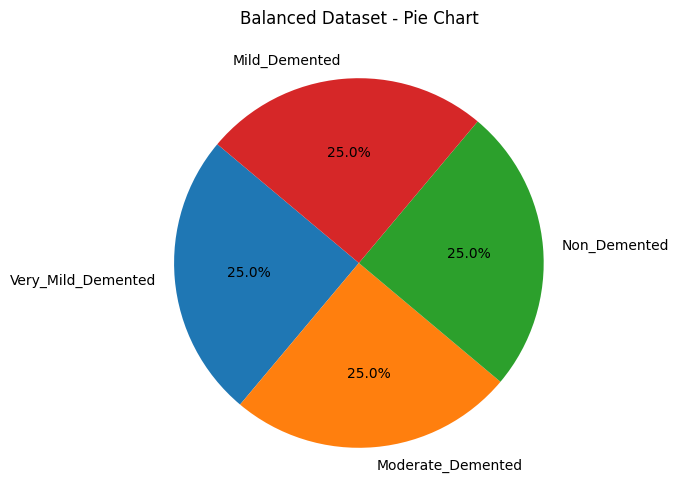

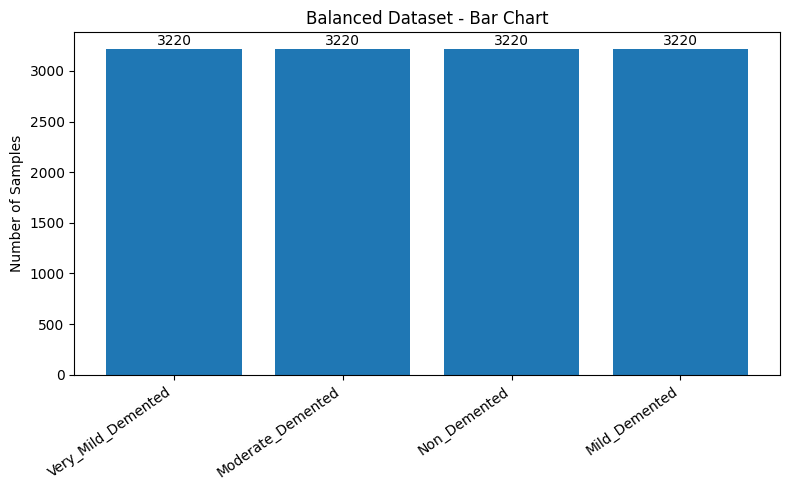

Train samples      : 9016
Validation samples : 1932
Test samples       : 1932


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Epoch 1 | Train Loss: 1.3162 | Train Acc: 0.3631 | Train F1: 0.3631 | Val Loss: 1.1353 | Val Acc: 0.5259 | Val F1: 0.5259
Epoch 2 | Train Loss: 0.8732 | Train Acc: 0.6095 | Train F1: 0.6095 | Val Loss: 0.6836 | Val Acc: 0.6636 | Val F1: 0.6636
Epoch 3 | Train Loss: 0.7024 | Train Acc: 0.6748 | Train F1: 0.6748 | Val Loss: 0.6196 | Val Acc: 0.7174 | Val F1: 0.7174
Epoch 4 | Train Loss: 0.6376 | Train Acc: 0.6990 | Train F1: 0.6990 | Val Loss: 0.5574 | Val Acc: 0.7391 | Val F1: 0.7391
Epoch 5 | Train Loss: 0.5648 | Train Acc: 0.7423 | Train F1: 0.7423 | Val Loss: 0.5183 | Val Acc: 0.7510 | Val F1: 0.7510
Epoch 6 | Train Loss: 0.4995 | Train Acc: 0.7815 | Train F1: 0.7815 | Val Loss: 0.4514 | Val Acc: 0.8054 | Val F1: 0.8054
Epoch 7 | Train Loss: 0.4373 | Train Acc: 0.8061 | Train F1: 0.8061 | Val Loss: 0.3945 | Val Acc: 0.8261 | Val F1: 0.8261
Epoch 8 | Train Loss: 0.3869 | Train Acc: 0.8358 | Train F1: 0.8358 | Val Loss: 0.3098 | Val Acc: 0.8706 | Val F1: 0.8706
Epoch 9 | Train Loss: 0.

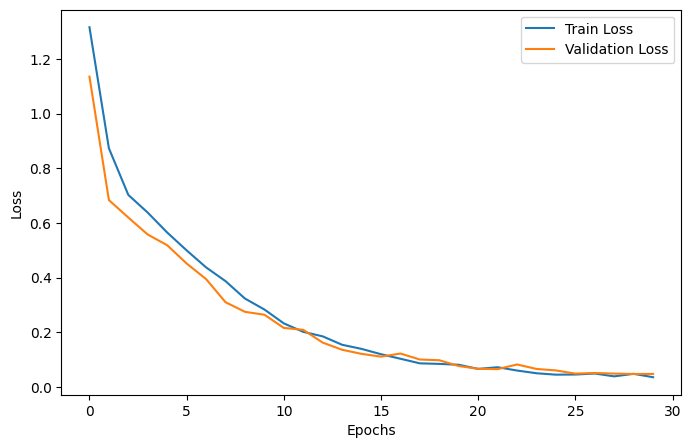

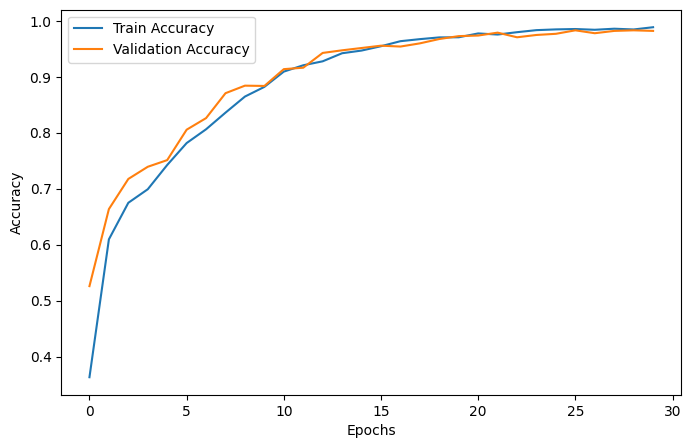

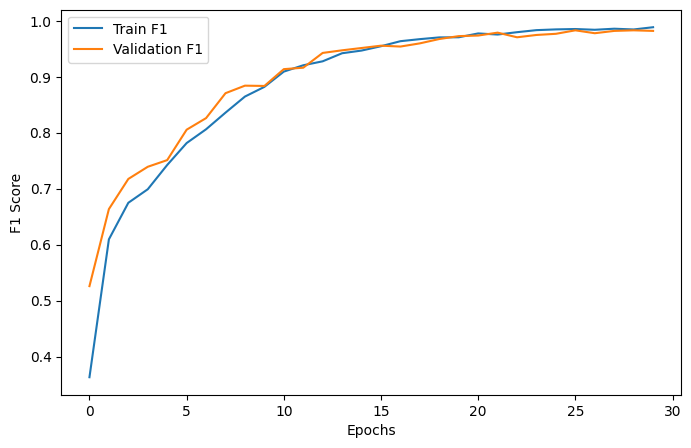


Classification Report

                    precision    recall  f1-score   support

Very_Mild_Demented       0.96      0.97      0.97       501
      Non_Demented       0.96      0.96      0.96       460
 Moderate_Demented       1.00      1.00      1.00       495
     Mild_Demented       1.00      0.99      0.99       476

          accuracy                           0.98      1932
         macro avg       0.98      0.98      0.98      1932
      weighted avg       0.98      0.98      0.98      1932



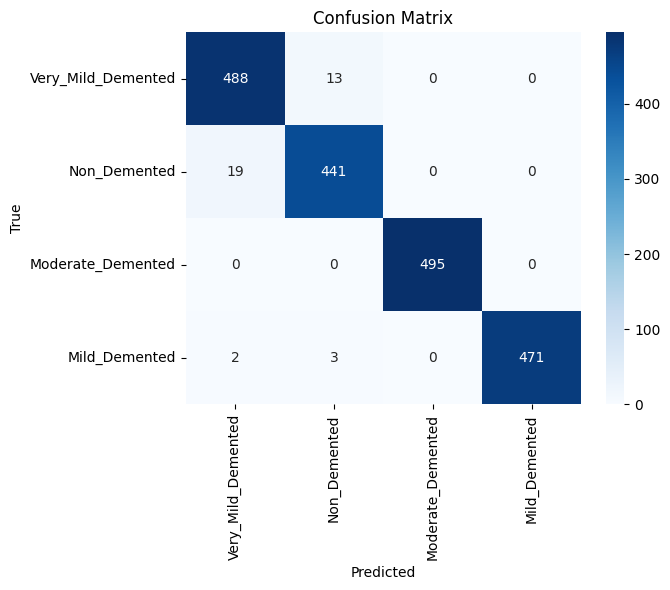

In [ ]:

# ============================================================##
# 0️⃣ Install Required Packages
# ============================================================##
!pip install timm torchmetrics scikit-learn matplotlib seaborn --quiet

# ============================================================##
# 1️⃣ Imports
# ============================================================##
import os, random
import numpy as np
import torch
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms as T
import torchmetrics
from sklearn.metrics import classification_report, confusion_matrix

# Set seeds for reproducibility
torch.manual_seed(2025)
np.random.seed(2025)
random.seed(2025)

# ============================================================##
# 2️⃣ Custom Dataset Class
# ============================================================##
class CustomDataset(Dataset):
    def __init__(self, root, transformations=None, im_files=(".png",".jpg",".jpeg")):
        self.transformations = transformations
        self.im_paths = []
        for ext in im_files:
            self.im_paths.extend(glob(os.path.join(root, "*", f"*{ext}")))

        self.cls_names = {}
        self.cls_counts = {}
        count = 0
        for p in self.im_paths:
            cls = self.get_class(p)
            if cls not in self.cls_names:
                self.cls_names[cls] = count
                self.cls_counts[cls] = 1
                count += 1
            else:
                self.cls_counts[cls] += 1

    def get_class(self, path):
        return os.path.basename(os.path.dirname(path))

    def __len__(self):
        return len(self.im_paths)

    def __getitem__(self, idx):
        img = Image.open(self.im_paths[idx]).convert("RGB")
        label = self.cls_names[self.get_class(self.im_paths[idx])]
        if self.transformations:
            img = self.transformations(img)
        return img, label

# ============================================================##
# 3️⃣ Balance Dataset
# ============================================================##
def balance_full_dataset(dataset):
    class_indices = {k: [] for k in dataset.cls_names}
    for i in range(len(dataset)):
        _, label = dataset[i]
        cls = list(dataset.cls_names.keys())[label]
        class_indices[cls].append(i)

    max_len = max(len(v) for v in class_indices.values())
    balanced_idx = []
    for v in class_indices.values():
        balanced_idx.extend(v + random.choices(v, k=max_len-len(v)))
    random.shuffle(balanced_idx)
    return Subset(dataset, balanced_idx)

# ============================================================##
# 4️⃣ Visualization
# ============================================================##
def visualize_dataset(counts, title):
    labels = list(counts.keys())
    values = list(counts.values())

    plt.figure(figsize=(6,6))
    plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=140)
    plt.title(f"{title} - Pie Chart")
    plt.show()

    plt.figure(figsize=(8,5))
    bars = plt.bar(labels, values)
    plt.title(f"{title} - Bar Chart")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=35, ha="right")
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
                 ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.show()

# ============================================================##
# 5️⃣ Dataset Setup with Augmentation
# ============================================================##
root = "/content/drive/MyDrive/Dataset"  # replace with your path
im_size = 224
bs = 32

tfs = T.Compose([
    T.Resize((im_size, im_size)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = CustomDataset(root, tfs)
visualize_dataset(dataset.cls_counts, "Original Dataset")

balanced_dataset = balance_full_dataset(dataset)
balanced_counts = {}
for _, lbl in balanced_dataset:
    balanced_counts[list(dataset.cls_names.keys())[lbl]] = balanced_counts.get(list(dataset.cls_names.keys())[lbl],0)+1
visualize_dataset(balanced_counts, "Balanced Dataset")

# Split dataset
total = len(balanced_dataset)
tr_len = int(0.7*total)
vl_len = int(0.15*total)
ts_len = total - tr_len - vl_len
print(f"Train samples      : {tr_len}")
print(f"Validation samples : {vl_len}")
print(f"Test samples       : {ts_len}")

train_ds, val_ds, test_ds = random_split(balanced_dataset, [tr_len, vl_len, ts_len])
train_dl = DataLoader(train_ds, bs, shuffle=True, num_workers=4)
val_dl   = DataLoader(val_ds, bs, shuffle=False, num_workers=4)
test_dl  = DataLoader(test_ds, 1, shuffle=False, num_workers=4)

# ============================================================##
# 6️⃣ TrainValidation Class
# ============================================================##
class TrainValidation:
    def __init__(self, model_name, classes, tr_dl, val_dl, device):
        self.model = timm.create_model(model_name, pretrained=True, num_classes=len(classes))

        # Add dropout to reduce overfitting
        in_features = self.model.fc.in_features
        self.model.fc = torch.nn.Sequential(
            torch.nn.Dropout(0.6),
            torch.nn.Linear(in_features, len(classes))
        )
        self.model = self.model.to(device)

        self.tr_dl = tr_dl
        self.val_dl = val_dl
        self.device = device

        self.loss_fn = torch.nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-4, weight_decay=1e-4)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='max', factor=0.5, patience=3)

        self.f1 = torchmetrics.F1Score(task="multiclass", num_classes=len(classes)).to(device)
        self.tr_losses, self.val_losses = [], []
        self.tr_accs, self.val_accs = [], []
        self.tr_f1s, self.val_f1s = [], []

        self.best_val_acc = 0
        self.patience = 7
        self.wait = 0

    def run(self, epochs=30):
        for e in range(epochs):
            # Train
            self.model.train()
            tl, ta = 0, 0
            self.f1.reset()
            for x, y in self.tr_dl:
                x, y = x.to(self.device), y.to(self.device)
                p = self.model(x)
                loss = self.loss_fn(p, y)
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                tl += loss.item()
                ta += (p.argmax(1)==y).sum().item()
                self.f1.update(p, y)
            tl /= len(self.tr_dl)
            ta /= len(self.tr_dl.dataset)
            tf1 = self.f1.compute().item()
            self.tr_losses.append(tl)
            self.tr_accs.append(ta)
            self.tr_f1s.append(tf1)

            # Validation
            self.model.eval()
            vl, va = 0, 0
            self.f1.reset()
            with torch.no_grad():
                for x, y in self.val_dl:
                    x, y = x.to(self.device), y.to(self.device)
                    p = self.model(x)
                    loss = self.loss_fn(p, y)
                    vl += loss.item()
                    va += (p.argmax(1)==y).sum().item()
                    self.f1.update(p, y)
            vl /= len(self.val_dl)
            va /= len(self.val_dl.dataset)
            vf1 = self.f1.compute().item()
            self.val_losses.append(vl)
            self.val_accs.append(va)
            self.val_f1s.append(vf1)

            # Scheduler step
            self.scheduler.step(va)

            print(f"Epoch {e+1} | Train Loss: {tl:.4f} | Train Acc: {ta:.4f} | Train F1: {tf1:.4f} | Val Loss: {vl:.4f} | Val Acc: {va:.4f} | Val F1: {vf1:.4f}")

            # Early stopping
            if va > self.best_val_acc:
                self.best_val_acc = va
                torch.save(self.model.state_dict(), "best_model.pth")
                self.wait = 0
            else:
                self.wait += 1
                if self.wait >= self.patience:
                    print("Early stopping (val accuracy not improving)")
                    break

# ============================================================##
# 7️⃣ Train Model
# ============================================================##
device = "cuda" if torch.cuda.is_available() else "cpu"
trainer = TrainValidation("resnet50", dataset.cls_names, train_dl, val_dl, device)
trainer.run(epochs=30)  # training for 30 epochs

# ============================================================##
# 8️⃣ Plot Learning Curves
# ============================================================##
plt.figure(figsize=(8,5))
plt.plot(trainer.tr_losses, label="Train Loss")
plt.plot(trainer.val_losses, label="Validation Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(trainer.tr_accs, label="Train Accuracy")
plt.plot(trainer.val_accs, label="Validation Accuracy")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(trainer.tr_f1s, label="Train F1")
plt.plot(trainer.val_f1s, label="Validation F1")
plt.xlabel("Epochs"); plt.ylabel("F1 Score"); plt.legend(); plt.show()

# ============================================================##
# 9️⃣ Evaluation + Metrics (Multi-Class)
# ============================================================##
trainer.model.load_state_dict(torch.load("best_model.pth"))
trainer.model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        p = trainer.model(x)
        y_true.append(y.item())
        y_pred.append(p.argmax(1).item())

print("\nClassification Report\n")
print(classification_report(y_true, y_pred, target_names=list(dataset.cls_names.keys())))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(dataset.cls_names.keys()),
            yticklabels=list(dataset.cls_names.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve
)

def compute_metrics(y_true, y_pred, y_prob, class_names):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro")
    sensitivity = recall_score(y_true, y_pred, average="macro")  # Recall
    cm = confusion_matrix(y_true, y_pred)

    # Specificity (macro)
    specificity = []
    for i in range(len(class_names)):
        tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
        fp = cm[:,i].sum() - cm[i,i]
        specificity.append(tn / (tn + fp + 1e-8))
    specificity = np.mean(specificity)

    # AUC (one-vs-rest for multiclass)
    auc = roc_auc_score(y_true, y_prob, multi_class="ovr")

    return acc, precision, sensitivity, specificity, auc

In [ ]:

trainer.model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        outputs = trainer.model(x)
        probs = torch.softmax(outputs, dim=1)

        y_true.append(y.item())
        y_pred.append(outputs.argmax(1).item())
        y_prob.append(probs.cpu().numpy()[0])

y_prob = np.array(y_prob)
class_names = list(dataset.cls_names.keys())

acc, prec, sens, spec, auc = compute_metrics(
    y_true, y_pred, y_prob, class_names
)

print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Sensitivity  : {sens:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"AUC (ROC)    : {auc:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Accuracy     : 0.9819
Precision    : 0.9822
Sensitivity  : 0.9816
Specificity  : 0.9939
AUC (ROC)    : 0.9993


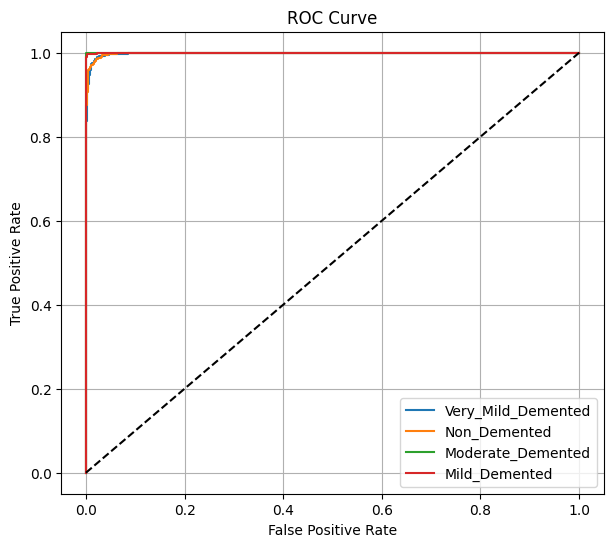

In [ ]:

plt.figure(figsize=(7,6))

for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        np.array(y_true) == i, y_prob[:, i]
    )
    plt.plot(fpr, tpr, label=f"{cls}")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [ ]:

# ============================================================
# 🔟 Grad-CAM for ResNet50 (timm)
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch


def get_last_conv_layer(model):
    """
    Safely get last convolution layer for ResNet (timm / torchvision)
    """
    block = model.layer4[-1]
    return block.conv3 if hasattr(block, "conv3") else block.conv2


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()

        output = self.model(input_tensor)
        score = output[:, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)

        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.squeeze().cpu().numpy()


def overlay_gradcam(image, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return cv2.addWeighted(image, 1 - alpha, heatmap, alpha, 0)


def run_gradcam(model, dataloader, class_names, device, num_images=6):
    model.eval()

    target_layer = get_last_conv_layer(model)
    gradcam = GradCAM(model, target_layer)

    shown = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        preds = model(images).argmax(dim=1)

        for i in range(images.size(0)):

            cam = gradcam.generate(
                images[i].unsqueeze(0),
                preds[i].item()
            )

            # Undo normalization for visualization
            img = images[i].permute(1, 2, 0).cpu().numpy()
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            img = np.uint8(255 * img)

            overlay = overlay_gradcam(img, cam)

            plt.figure(figsize=(4, 4))
            plt.imshow(overlay)
            plt.title(
                f"Pred: {list(class_names.keys())[preds[i].item()]} | "
                f"True: {list(class_names.keys())[labels[i].item()]}"
            )
            plt.axis("off")
            plt.show()

            shown += 1
            if shown >= num_images:
                return

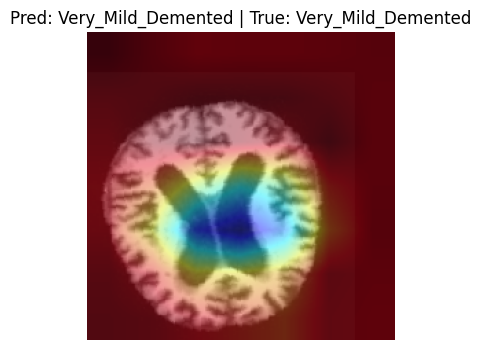

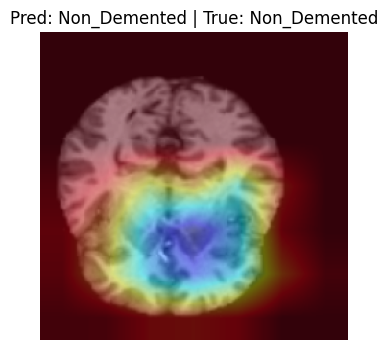

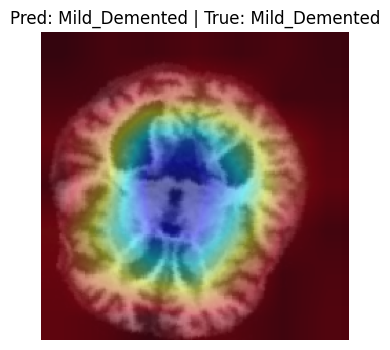

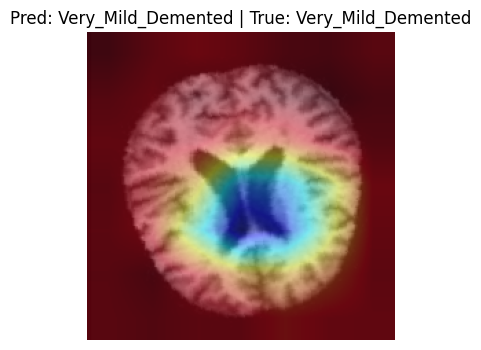

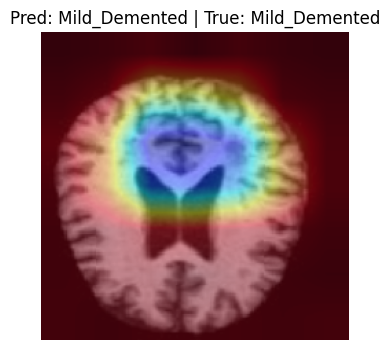

In [ ]:

run_gradcam(
    trainer.model,
    test_dl,
    dataset.cls_names,
    device,
    num_images=5
)

In [ ]:

import os
import torch
import numpy as np
from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms as T

torch.manual_seed(2025)

class CustomDataset(Dataset):
    def __init__(self, root, transformations=None, im_files=(".png", ".jpg", ".jpeg")):
        self.transformations = transformations

        # Collect image paths correctly
        self.im_paths = []
        for ext in im_files:
            self.im_paths.extend(
                glob(os.path.join(root, "*", f"*{ext}"))
            )

        # Create class mapping
        self.cls_names = {}
        self.cls_counts = {}
        count = 0

        for im_path in self.im_paths:
            class_name = self.get_class(im_path)
            if class_name not in self.cls_names:
                self.cls_names[class_name] = count
                self.cls_counts[class_name] = 1
                count += 1
            else:
                self.cls_counts[class_name] += 1

    def get_class(self, path):
        return os.path.basename(os.path.dirname(path))

    def __len__(self):
        return len(self.im_paths)

    def __getitem__(self, idx):
        im_path = self.im_paths[idx]
        image = Image.open(im_path).convert("RGB")
        label = self.cls_names[self.get_class(im_path)]

        if self.transformations:
            image = self.transformations(image)

        return image, label

    @classmethod
    def get_dls(cls, root, transformations, bs, split=(0.7, 0.15, 0.15), ns=4):
        dataset = cls(root=root, transformations=transformations)

        total_len = len(dataset)
        tr_len = int(total_len * split[0])
        vl_len = int(total_len * split[1])
        ts_len = total_len - tr_len - vl_len

        tr_ds, vl_ds, ts_ds = random_split(
            dataset, [tr_len, vl_len, ts_len]
        )

        tr_dl = DataLoader(tr_ds, batch_size=bs, shuffle=True, num_workers=ns)
        vl_dl = DataLoader(vl_ds, batch_size=bs, shuffle=False, num_workers=ns)
        ts_dl = DataLoader(ts_ds, batch_size=1, shuffle=False, num_workers=ns)

        return tr_dl, vl_dl, ts_dl, dataset.cls_names, dataset.cls_counts

In [ ]:

root = "/content/drive/MyDrive/Dataset"

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
im_size = 224
bs = 32

tfs = T.Compose([
    T.Resize((im_size, im_size)),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])

tr_dl, val_dl, ts_dl, classes, cls_counts = CustomDataset.get_dls(
    root=root,
    transformations=tfs,
    bs=bs
)

print("Train batches:", len(tr_dl))
print("Val batches:", len(val_dl))
print("Test samples:", len(ts_dl))
print("Class mapping:", classes)
print("Class counts:", cls_counts)

Train batches: 141
Val batches: 31
Test samples: 963
Class mapping: {'Very_Mild_Demented': 0, 'Non_Demented': 1, 'Moderate_Demented': 2, 'Mild_Demented': 3}
Class counts: {'Very_Mild_Demented': 2240, 'Non_Demented': 3220, 'Moderate_Demented': 64, 'Mild_Demented': 896}


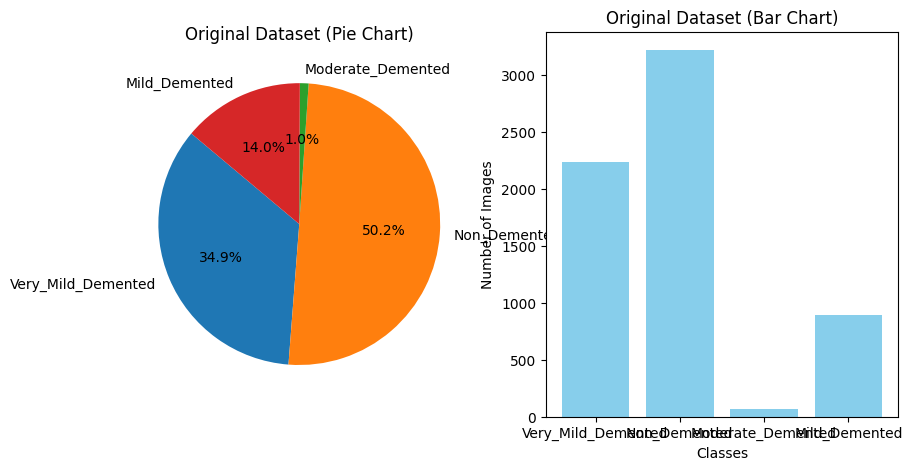

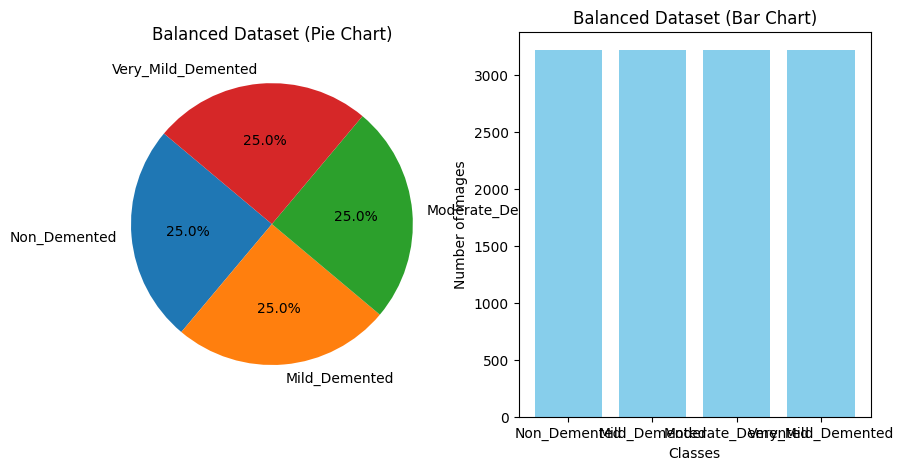

Start training...

Epoch 1/100:



Training: 282it [01:08,  4.15it/s]

1-epoch train process is completed!

1-epoch train loss     -> 0.690
1-epoch train accuracy -> 0.764
1-epoch train f1-score -> 0.764




Validation: 61it [00:09,  6.63it/s]


1-epoch validation process is completed!

1-epoch validation loss     -> 0.306
1-epoch validation accuracy -> 0.881
1-epoch validation f1-score -> 0.881

Best model saved with F1-Score: 0.881

Epoch 2/100:



...

8-epoch validation process is completed!

8-epoch validation loss     -> 0.217
8-epoch validation accuracy -> 0.948
8-epoch validation f1-score -> 0.948

No improvement for 2 epoch(s).

Epoch 9/100:




Training: 282it [01:09,  4.05it/s]

9-epoch train process is completed!

9-epoch train loss     -> 0.052
9-epoch train accuracy -> 0.983
9-epoch train f1-score -> 0.983




Validation: 61it [00:08,  7.34it/s]

9-epoch validation process is completed!

9-epoch validation loss     -> 0.070
9-epoch validation accuracy -> 0.978
9-epoch validation f1-score -> 0.978

No improvement for 3 epoch(s).
Early stopping triggered.


In [ ]:

# -------------------------
# 0️⃣ Install Required Packages
# -------------------------
!pip install torchmetrics matplotlib --quiet

# -------------------------
# 1️⃣ Imports
# -------------------------
import os
import random
from glob import glob
from collections import Counter
import matplotlib.pyplot as plt

import torch
import torchmetrics
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from PIL import Image
from torchvision import transforms as T
import timm
from tqdm import tqdm

# -------------------------
# 2️⃣ Custom Dataset Class
# -------------------------
class CustomDataset(Dataset):
    def __init__(self, root, transformations=None, im_files=(".png", ".jpg", ".jpeg")):
        self.transformations = transformations
        self.im_paths = []
        for ext in im_files:
            self.im_paths.extend(glob(os.path.join(root, "*", f"*{ext}")))

        # Class mapping and counts
        self.cls_names = {}
        self.cls_counts = {}
        count = 0
        for im_path in self.im_paths:
            cls_name = self.get_class(im_path)
            if cls_name not in self.cls_names:
                self.cls_names[cls_name] = count
                self.cls_counts[cls_name] = 1
                count += 1
            else:
                self.cls_counts[cls_name] += 1

    def get_class(self, path):
        return os.path.basename(os.path.dirname(path))

    def __len__(self):
        return len(self.im_paths)

    def __getitem__(self, idx):
        im_path = self.im_paths[idx]
        image = Image.open(im_path).convert("RGB")
        label = self.cls_names[self.get_class(im_path)]
        if self.transformations:
            image = self.transformations(image)
        return image, label

# -------------------------
# 3️⃣ Balance Dataset
# -------------------------
def balance_full_dataset(dataset):
    class_indices = {cls: [] for cls in dataset.cls_names.keys()}
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        cls_name = list(dataset.cls_names.keys())[label]
        class_indices[cls_name].append(idx)

    max_count = max(len(idxs) for idxs in class_indices.values())
    balanced_indices = []
    for cls, idxs in class_indices.items():
        if len(idxs) < max_count:
            extra_idxs = random.choices(idxs, k=max_count - len(idxs))
            balanced_indices.extend(idxs + extra_idxs)
        else:
            balanced_indices.extend(idxs)
    random.shuffle(balanced_indices)
    return Subset(dataset, balanced_indices)

# -------------------------
# 4️⃣ Visualization Function
# -------------------------
def visualize_dataset(cls_counts, title="Dataset Distribution"):
    labels = list(cls_counts.keys())
    counts = list(cls_counts.values())

    # Pie chart
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.pie(counts, labels=labels, autopct="%1.1f%%", startangle=140)
    plt.title(title + " (Pie Chart)")

    # Bar chart
    plt.subplot(1,2,2)
    plt.bar(labels, counts, color="skyblue")
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.title(title + " (Bar Chart)")
    plt.show()

# -------------------------
# 5️⃣ Dataset Setup
# -------------------------
root = "/content/drive/MyDrive/Dataset"  # Change to your dataset path
im_size = 224
bs = 32
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

tfs = T.Compose([
    T.Resize((im_size, im_size)),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])

# Original dataset
dataset = CustomDataset(root=root, transformations=tfs)

# Visualize original dataset
visualize_dataset(dataset.cls_counts, title="Original Dataset")

# Balanced dataset
balanced_dataset = balance_full_dataset(dataset)

# Compute balanced class counts
balanced_counts = Counter()
for _, label in balanced_dataset:
    cls_name = list(dataset.cls_names.keys())[label]
    balanced_counts[cls_name] += 1

# Visualize balanced dataset
visualize_dataset(balanced_counts, title="Balanced Dataset")

# -------------------------
# 6️⃣ Split Dataset
# -------------------------
total_len = len(balanced_dataset)
tr_len = int(total_len * 0.7)
vl_len = int(total_len * 0.15)
ts_len = total_len - tr_len - vl_len

train_ds, val_ds, test_ds = random_split(
    balanced_dataset, [tr_len, vl_len, ts_len]
)

train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=4)
val_dl   = DataLoader(val_ds, batch_size=bs, shuffle=False, num_workers=4)
test_dl  = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=4)

classes = dataset.cls_names

# -------------------------
# 7️⃣ TrainValidation Class
# -------------------------
class TrainValidation:
    def __init__(self, model_name, classes, tr_dl, val_dl, device, save_dir="saved_models",
                 save_prefix="model", lr=3e-4, epochs=100, patience=5, threshold=0.01, dev_mode=False):
        self.model_name = model_name
        self.classes = classes
        self.tr_dl = tr_dl
        self.val_dl = val_dl
        self.save_dir = save_dir
        self.save_prefix = save_prefix
        self.lr = lr
        self.epochs = epochs
        self.patience = patience
        self.threshold = threshold
        self.dev_mode = dev_mode
        self.device = device

        self.model = timm.create_model(model_name, pretrained=True, num_classes=len(classes)).to(device)
        self.loss_fn = torch.nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.f1_metric = torchmetrics.F1Score(task="multiclass", num_classes=len(classes)).to(device)

        os.makedirs(save_dir, exist_ok=True)

        self.best_loss = float("inf")
        self.best_acc = 0
        self.not_improved = 0

        self.tr_losses, self.val_losses = [], []
        self.tr_accs, self.val_accs = [], []
        self.tr_f1s, self.val_f1s = [], []

    @staticmethod
    def to_device(batch, device):
        ims, gts = batch
        return ims.to(device), gts.to(device)

    def train_epoch(self):
        self.model.train()
        train_loss, train_acc = 0.0, 0.0
        self.f1_metric.reset()
        for idx, batch in tqdm(enumerate(self.tr_dl), desc="Training"):
            if self.dev_mode and idx == 1: break
            ims, gts = TrainValidation.to_device(batch, self.device)
            preds = self.model(ims)
            loss = self.loss_fn(preds, gts)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            train_loss += loss.item()
            train_acc += (torch.argmax(preds, dim=1) == gts).sum().item()
            self.f1_metric.update(preds, gts)
        train_loss /= len(self.tr_dl)
        train_acc /= len(self.tr_dl.dataset)
        train_f1 = self.f1_metric.compute().item()
        self.tr_losses.append(train_loss)
        self.tr_accs.append(train_acc)
        self.tr_f1s.append(train_f1)
        return train_loss, train_acc, train_f1

    def validate_epoch(self):
        self.model.eval()
        val_loss, val_acc = 0.0, 0.0
        self.f1_metric.reset()
        with torch.no_grad():
            for idx, batch in tqdm(enumerate(self.val_dl), desc="Validation"):
                if self.dev_mode and idx == 1: break
                ims, gts = TrainValidation.to_device(batch, self.device)
                preds = self.model(ims)
                loss = self.loss_fn(preds, gts)
                val_loss += loss.item()
                val_acc += (torch.argmax(preds, dim=1) == gts).sum().item()
                self.f1_metric.update(preds, gts)
        val_loss /= len(self.val_dl)
        val_acc /= len(self.val_dl.dataset)
        val_f1 = self.f1_metric.compute().item()
        self.val_losses.append(val_loss)
        self.val_accs.append(val_acc)
        self.val_f1s.append(val_f1)
        return val_loss, val_acc, val_f1

    def save_best_model(self, val_f1, val_loss):
        if val_f1 > self.best_acc + self.threshold:
            self.best_acc = val_f1
            save_path = os.path.join(self.save_dir, f"{self.save_prefix}_best_model.pth")
            torch.save(self.model.state_dict(), save_path)
            print(f"Best model saved with F1-Score: {self.best_acc:.3f}")
            self.not_improved = 0
        else:
            self.not_improved += 1
            print(f"No improvement for {self.not_improved} epoch(s).")

    def verbose(self, epoch, metric1, metric2, metric3, process="train"):
        print(f"{epoch + 1}-epoch {process} process is completed!\n")
        print(f"{epoch + 1}-epoch {process} loss     -> {metric1:.3f}")
        print(f"{epoch + 1}-epoch {process} accuracy -> {metric2:.3f}")
        print(f"{epoch + 1}-epoch {process} f1-score -> {metric3:.3f}\n")

    def run(self):
        print("Start training...")
        for epoch in range(self.epochs):
            if self.dev_mode and epoch == 1: break
            print(f"\nEpoch {epoch + 1}/{self.epochs}:\n")
            train_loss, train_acc, train_f1 = self.train_epoch()
            self.verbose(epoch, train_loss, train_acc, train_f1, process="train")
            val_loss, val_acc, val_f1 = self.validate_epoch()
            self.verbose(epoch, val_loss, val_acc, val_f1, process="validation")
            self.save_best_model(val_f1, val_loss)
            if self.not_improved >= self.patience:
                print("Early stopping triggered.")
                break

# -------------------------
# 8️⃣ Instantiate & Run
# -------------------------
model_name   = "rexnet_150"
save_prefix  = "mri"
device       = "cuda" if torch.cuda.is_available() else "cpu"

trainer = TrainValidation(
    model_name=model_name,
    device=device,
    save_prefix=save_prefix,
    classes=classes,
    tr_dl=train_dl,
    val_dl=val_dl,
    patience=3,
    dev_mode=False
)

trainer.run()

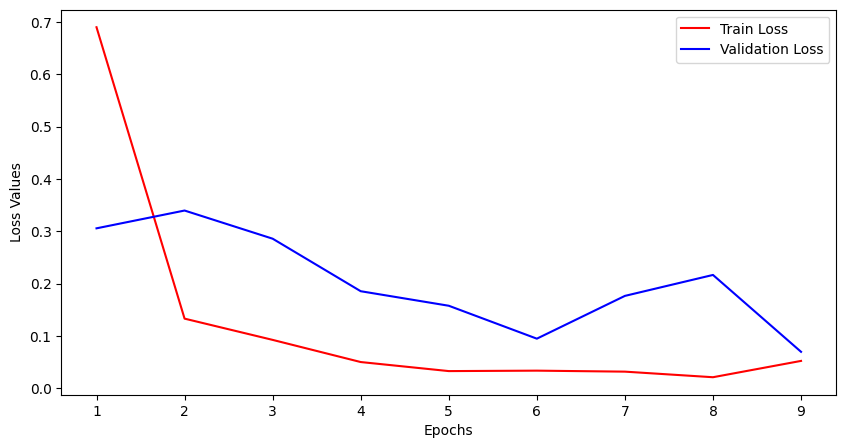

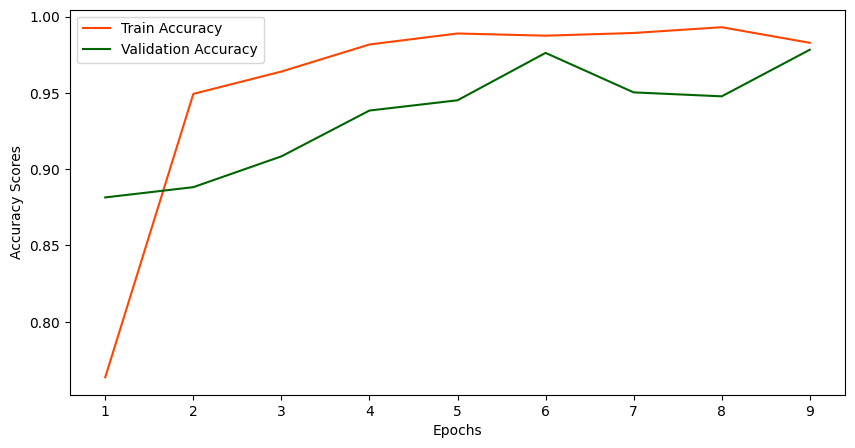

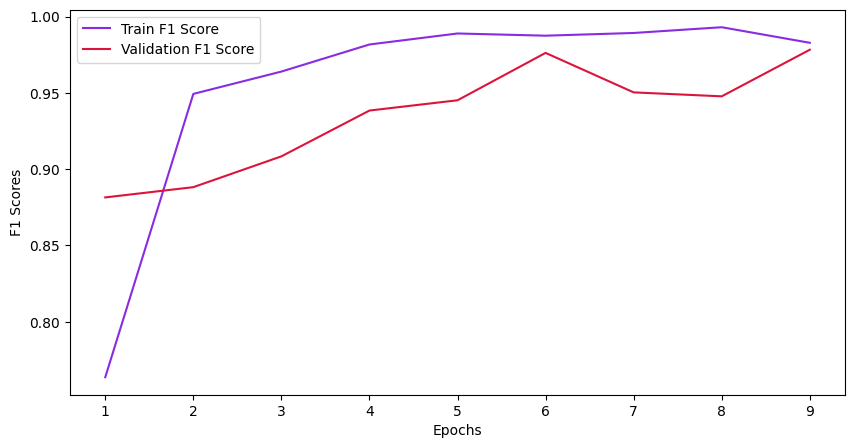

In [ ]:


 class PlotLearningCurves:

    def __init__(self, tr_losses, val_losses, tr_accs, val_accs, tr_f1s, val_f1s):

        self.tr_losses, self.val_losses, self.tr_accs, self.val_accs, self.tr_f1s, self.val_f1s = tr_losses, val_losses, tr_accs, val_accs, tr_f1s, val_f1s

    def plot(self, array_1, array_2, label_1, label_2, color_1, color_2):

        plt.plot(array_1, label = label_1, c = color_1); plt.plot(array_2, label = label_2, c = color_2)

    def create_figure(self): plt.figure(figsize = (10, 5))

    def decorate(self, ylabel, xlabel = "Epochs"):

        plt.xlabel(xlabel); plt.ylabel(ylabel)
        plt.xticks(ticks = np.arange(len(self.tr_accs)), labels = [i for i in range(1, len(self.tr_accs) + 1)])
        plt.legend(); plt.show()

    def visualize(self):

        # Figure 1
        self.create_figure()
        self.plot(array_1 = self.tr_losses, array_2 = self.val_losses, label_1 = "Train Loss", label_2 = "Validation Loss", color_1 = "red", color_2 = "blue"); self.decorate(ylabel = "Loss Values")

        # Figure 2
        self.create_figure()
        self.plot(array_1 = self.tr_accs, array_2 = self.val_accs, label_1 = "Train Accuracy", label_2 = "Validation Accuracy", color_1 = "orangered", color_2 = "darkgreen")
        self.decorate(ylabel = "Accuracy Scores")

        # Figure 3
        self.create_figure()
        self.plot(array_1 = self.tr_f1s, array_2 = self.val_f1s, label_1 = "Train F1 Score", label_2 = "Validation F1 Score", color_1 = "blueviolet", color_2 = "crimson"); self.decorate(ylabel = "F1 Scores")

PlotLearningCurves(tr_losses=trainer.tr_losses, val_losses=trainer.val_losses, tr_accs=trainer.tr_accs, val_accs=trainer.val_accs, tr_f1s=trainer.tr_f1s, val_f1s=trainer.val_f1s).visualize()

In [ ]:

# -------------------------
# 9️⃣ Evaluator for Test Dataset
# -------------------------
class Evaluator:
    def __init__(self, model, test_dl, classes, device):
        self.model = model
        self.test_dl = test_dl
        self.classes = classes
        self.device = device

        # Metrics
        num_classes = len(classes)
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(device)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro').to(device)
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro').to(device)
        self.f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device)

    @staticmethod
    def to_device(batch, device):
        ims, gts = batch
        return ims.to(device), gts.to(device)

    def evaluate(self):
        self.model.eval()
        self.accuracy.reset()
        self.precision.reset()
        self.recall.reset()
        self.f1.reset()

        with torch.no_grad():
            for batch in tqdm(self.test_dl, desc="Evaluating"):
                ims, gts = Evaluator.to_device(batch, self.device)
                preds = self.model(ims)
                preds_labels = torch.argmax(preds, dim=1)

                # Update metrics
                self.accuracy.update(preds_labels, gts)
                self.precision.update(preds_labels, gts)
                self.recall.update(preds_labels, gts)
                self.f1.update(preds_labels, gts)

        # Compute final metrics
        acc = self.accuracy.compute().item()
        prec = self.precision.compute().item()
        rec = self.recall.compute().item()
        f1_score = self.f1.compute().item()

        print(f"\nTest Dataset Evaluation:")
        print(f"Accuracy  : {acc:.3f}")
        print(f"Precision : {prec:.3f}")
        print(f"Recall    : {rec:.3f}")
        print(f"F1-Score  : {f1_score:.3f}")

        return acc, prec, rec, f1_score

# -------------------------
# 10️⃣ Run Evaluator on Test Dataset
# -------------------------
# Load the best model first
best_model_path = os.path.join(trainer.save_dir, f"{trainer.save_prefix}_best_model.pth")
trainer.model.load_state_dict(torch.load(best_model_path, map_location=trainer.device))

# Evaluate
evaluator = Evaluator(model=trainer.model, test_dl=test_dl, classes=classes, device=device)
acc, prec, rec, f1_score = evaluator.evaluate()

Evaluating:   0%|          | 0/1932 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Evaluating: 100%|██████████| 1932/1932 [00:39<00:00, 48.59it/s]


Test Dataset Evaluation:
Accuracy  : 0.978
Precision : 0.978
Recall    : 0.978
F1-Score  : 0.978


In [ ]:

import matplotlib.pyplot as plt
import torchmetrics

In [ ]:

# -------------------------
# 🔟 Confusion Matrix
# -------------------------
class ConfusionMatrixEvaluator:
    def __init__(self, model, test_dl, classes, device):
        self.model = model
        self.test_dl = test_dl
        self.classes = classes
        self.device = device

        self.class_names = list(classes.keys())
        self.num_classes = len(self.class_names)

        self.cm_metric = torchmetrics.ConfusionMatrix(
            task="multiclass",
            num_classes=self.num_classes
        ).to(device)

    def evaluate(self):
        self.model.eval()
        self.cm_metric.reset()

        with torch.no_grad():
            for ims, gts in tqdm(self.test_dl, desc="Confusion Matrix"):
                ims = ims.to(self.device)
                gts = gts.to(self.device)

                outputs = self.model(ims)
                preds = torch.argmax(outputs, dim=1)

                self.cm_metric.update(preds, gts)

        cm = self.cm_metric.compute().cpu().numpy()
        self.plot_confusion_matrix(cm)

        return cm

    def plot_confusion_matrix(self, cm):
        plt.figure(figsize=(7, 6))
        plt.imshow(cm, interpolation="nearest")
        plt.title("Confusion Matrix (Test Dataset)")
        plt.colorbar()

        tick_marks = range(len(self.class_names))
        plt.xticks(tick_marks, self.class_names, rotation=45)
        plt.yticks(tick_marks, self.class_names)

        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")

        # Annotate cells
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j],
                         horizontalalignment="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black")

        plt.tight_layout()
        plt.show()

Confusion Matrix: 100%|██████████| 1932/1932 [00:35<00:00, 54.00it/s]


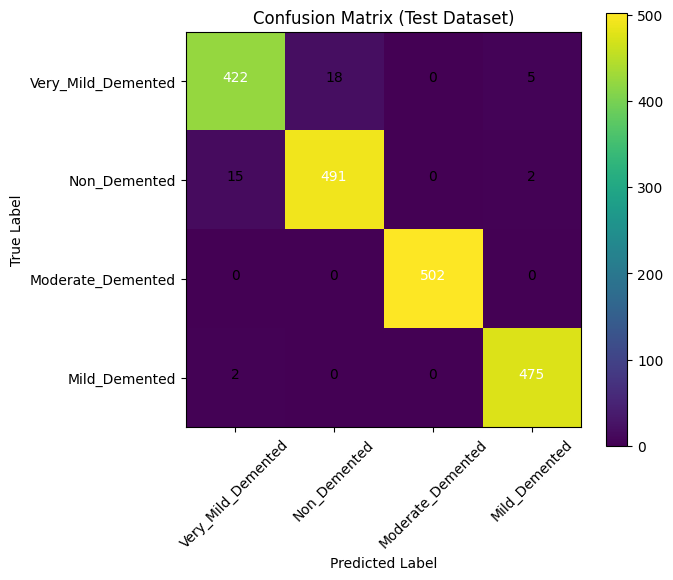

In [ ]:

# Load best model
best_model_path = os.path.join(trainer.save_dir, f"{trainer.save_prefix}_best_model.pth")
trainer.model.load_state_dict(torch.load(best_model_path, map_location=device))

# Confusion matrix evaluation
cm_evaluator = ConfusionMatrixEvaluator(
    model=trainer.model,
    test_dl=test_dl,
    classes=classes,
    device=device
)

conf_matrix = cm_evaluator.evaluate()

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

# -------------------------
# 🔥 Grad-CAM Implementation
# -------------------------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        outputs = self.model(input_tensor)

        if class_idx is None:
            class_idx = outputs.argmax(dim=1).item()

        loss = outputs[:, class_idx]
        loss.backward()

        # Global Average Pooling of gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])

        # Weight activations
        for i in range(self.activations.shape[1]):
            self.activations[:, i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = torch.relu(heatmap)
        heatmap /= torch.max(heatmap)

        return heatmap.cpu().numpy()

In [ ]:

def get_last_conv_layer(model):
    for module in reversed(list(model.modules())):
        if isinstance(module, torch.nn.Conv2d):
            return module
    raise ValueError("No Conv2D layer found in the model.")

In [ ]:

def overlay_gradcam(image, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(image, 1 - alpha, heatmap, alpha, 0)
    return overlay

In [ ]:

# -------------------------
# 🔥 Grad-CAM Evaluation
# -------------------------
def run_gradcam(model, test_dl, classes, device, num_images=4):
    model.eval()

    class_names = list(classes.keys())
    target_layer = get_last_conv_layer(model)
    gradcam = GradCAM(model, target_layer)

    shown = 0

    for images, labels in test_dl:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        for i in range(images.size(0)):
            img = images[i].cpu()
            label = labels[i].item()
            pred = preds[i].item()

            # Reverse normalization
            img_np = img.permute(1, 2, 0).numpy()
            img_np = img_np * np.array(std) + np.array(mean)
            img_np = np.clip(img_np, 0, 1)
            img_np = np.uint8(255 * img_np)

            heatmap = gradcam.generate(images[i].unsqueeze(0), class_idx=pred)
            overlay = overlay_gradcam(img_np, heatmap)

            plt.figure(figsize=(10, 4))

            plt.subplot(1, 3, 1)
            plt.imshow(img_np)
            plt.title("Original Image")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.imshow(heatmap, cmap="jet")
            plt.title("Grad-CAM Heatmap")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.imshow(overlay)
            plt.title(
                f"Overlay\nTrue: {class_names[label]} | Pred: {class_names[pred]}"
            )
            plt.axis("off")

            plt.tight_layout()
            plt.show()

            shown += 1
            if shown >= num_images:
                return

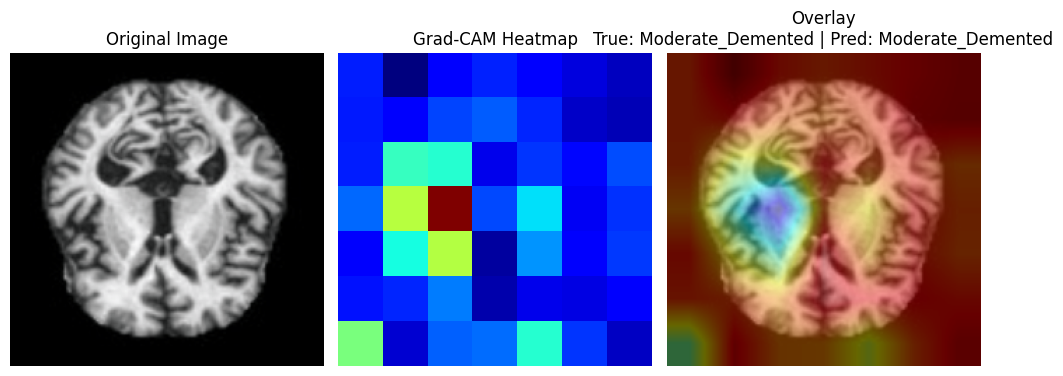

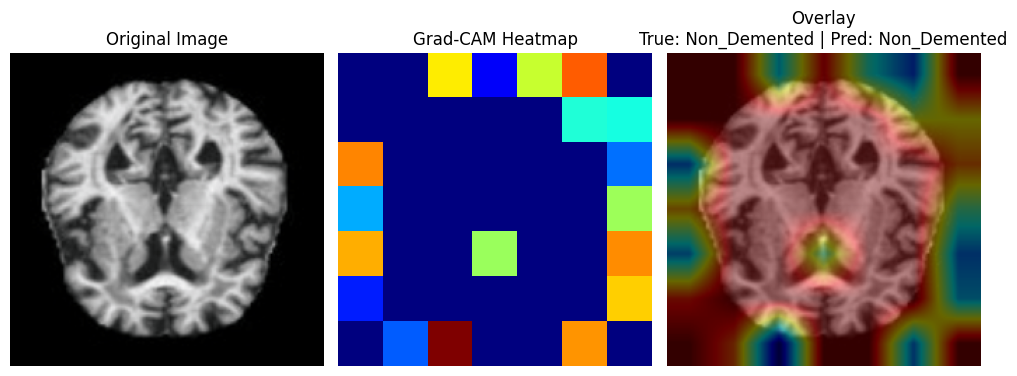

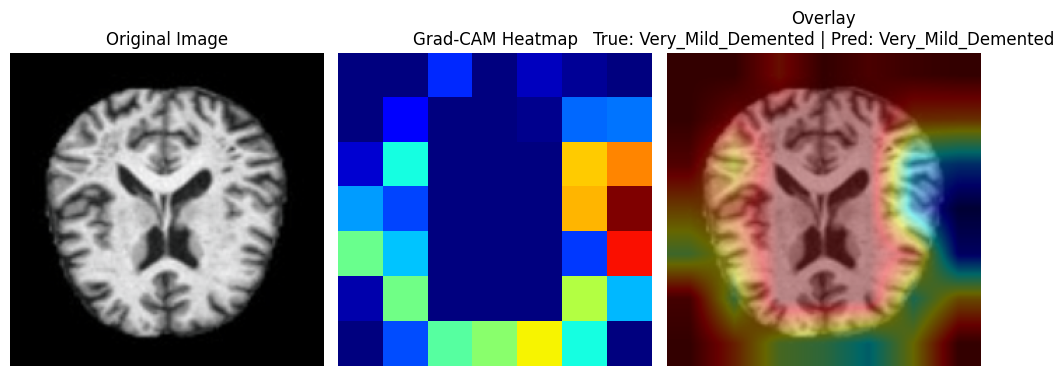

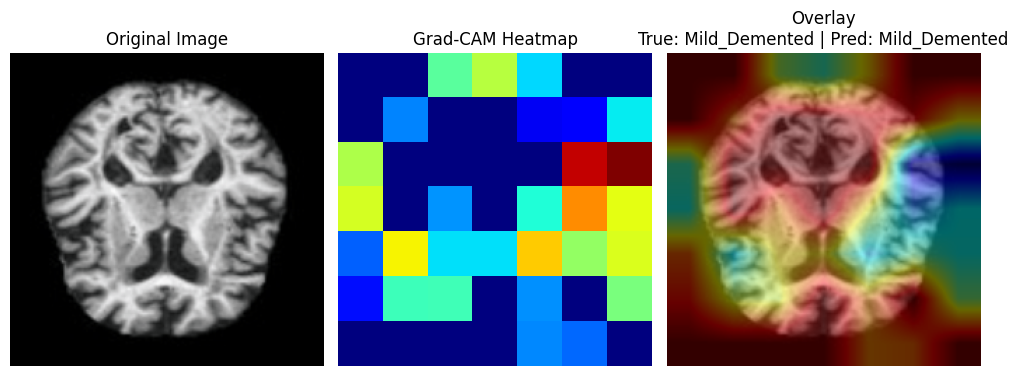

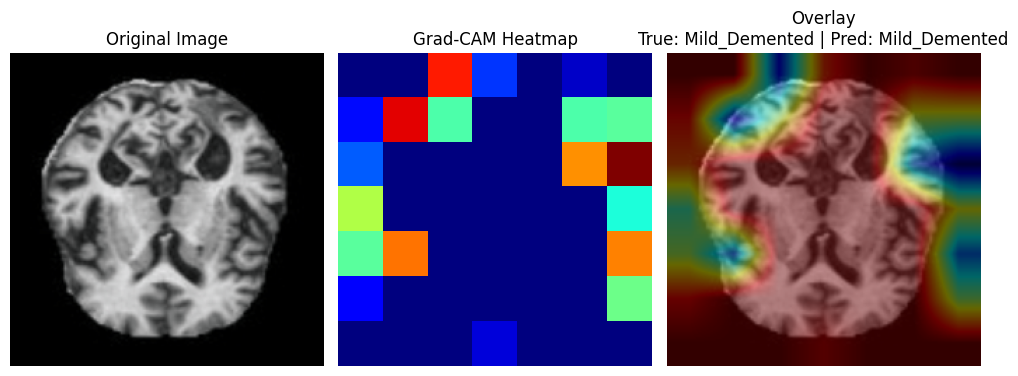

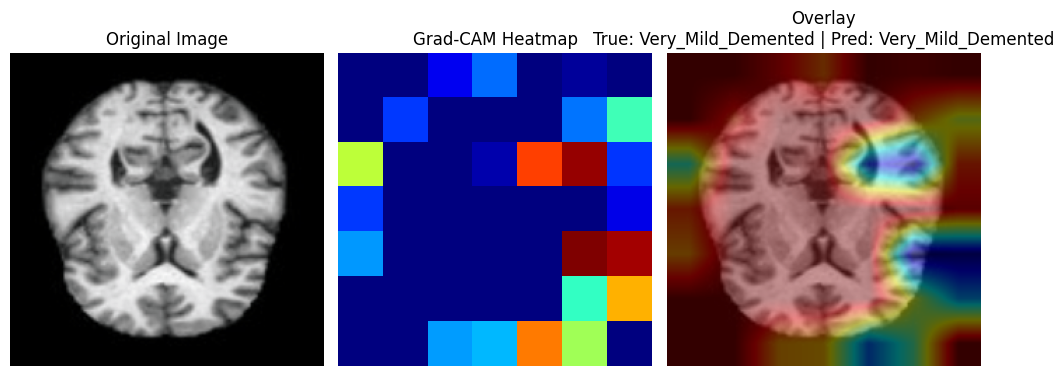

In [ ]:

# Load best model
best_model_path = os.path.join(trainer.save_dir, f"{trainer.save_prefix}_best_model.pth")
trainer.model.load_state_dict(torch.load(best_model_path, map_location=device))

# Run Grad-CAM
run_gradcam(
    model=trainer.model,
    test_dl=test_dl,
    classes=classes,
    device=device,
    num_images=6
)